### **Import libraries**

In [3]:
pip install keras-tuner

Note: you may need to restart the kernel to use updated packages.


In [1]:
from keras.callbacks import EarlyStopping,ReduceLROnPlateau,ModelCheckpoint,TensorBoard,LambdaCallback
from keras.layers import Input,Dropout, Dense,GlobalAveragePooling2D
from keras.models import Sequential,Model
from keras.layers import Dense, Dropout ,Flatten 
from tensorflow.keras.constraints import MaxNorm 
from tensorflow.keras.optimizers import Adam, SGD, RMSprop
from keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.utils import to_categorical
from keras import backend as K 
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix,classification_report
from sklearn.utils import shuffle
import matplotlib.pyplot as plt
from tensorflow import keras
import tensorflow as tf
from tqdm import tqdm
import seaborn as sns
import numpy as np
import itertools 
import datetime
import cv2
import os
import io
import keras_tuner as kt

### **Data Preparation**

In [9]:
import os
import cv2
import numpy as np
from tqdm import tqdm

# Labels for the different classes of tumors
labels = ['glioma', 'meningioma', 'notumor', 'pituitary']

# Lists to store the training and testing data
x_train = []
y_train = []
x_test = []
y_test = []

# Define the desired image size
image_size = 200

# Define the root dataset directory relative to the notebook's location
dataset_dir = "./Brain_Tumor"

# Loop through each label (class) directory
for label in labels:
    # Define paths for training and testing data
    trainPath = os.path.join(dataset_dir, "Training", label)
    testPath = os.path.join(dataset_dir, "Testing", label)
    
    # Load and preprocess the training images
    for file in tqdm(os.listdir(trainPath)):
        image = cv2.imread(os.path.join(trainPath, file), 0)  # Load image in grayscale
        image = cv2.bilateralFilter(image, 2, 50, 50)  # Apply bilateral filter
        image = cv2.resize(image, (image_size, image_size))  # Resize image
        x_train.append(image)  # Add image to training data list
        y_train.append(labels.index(label))  # Add corresponding label
    
    # Load and preprocess the testing images
    for file in tqdm(os.listdir(testPath)):
        image = cv2.imread(os.path.join(testPath, file), 0)  # Load image in grayscale
        image = cv2.bilateralFilter(image, 2, 50, 50)  # Apply bilateral filter
        image = cv2.resize(image, (image_size, image_size))  # Resize image
        x_test.append(image)  # Add image to testing data list
        y_test.append(labels.index(label))  # Add corresponding label

# Convert the lists to numpy arrays and normalize the pixel values to [0, 1]
x_train = np.array(x_train)[..., np.newaxis] / 255.0  # Add a channel dimension
x_test = np.array(x_test)[..., np.newaxis] / 255.0  # Add a channel dimension

# Convert the labels to numpy arrays
y_train = np.array(y_train)
y_test = np.array(y_test)

# Print the shape of the datasets
print("Training data shape:", x_train.shape)
print("Test data shape:", x_test.shape)


100%|██████████| 300/300 [00:02<00:00, 111.77it/s]


Training data shape: (5712, 200, 200, 1)
Test data shape: (1311, 200, 200, 1)


### **Data Visualization**

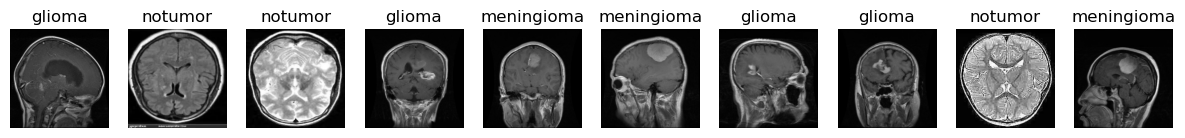

In [10]:
def visualize_data(images, labels, label_names, num_samples=10):
    plt.figure(figsize=(15, 15))
    for i in range(num_samples):
        idx = np.random.randint(0, len(images))
        plt.subplot(1, num_samples, i + 1)
        plt.imshow(images[idx].squeeze(), cmap='gray')
        plt.title(label_names[labels[idx]])
        plt.axis('off')
    plt.show()

visualize_data(x_train, y_train, labels, num_samples=10)



In [11]:

x_train, y_train = shuffle(x_train, y_train, random_state=42)
y_train = tf.keras.utils.to_categorical(y_train, num_classes=len(labels))
y_test = tf.keras.utils.to_categorical(y_test, num_classes=len(labels))

x_train, x_val, y_train, y_val = train_test_split(x_train, y_train, test_size=0.2, random_state=42)

print("Validation data shape:", x_val.shape)

Validation data shape: (1143, 200, 200, 1)


### **Data Augmentation**

In [12]:
datagen = ImageDataGenerator(
    rotation_range=10,                        
    width_shift_range=0.05,
    height_shift_range=0.05,
    featurewise_std_normalization=True)


datagen.fit(x_train)

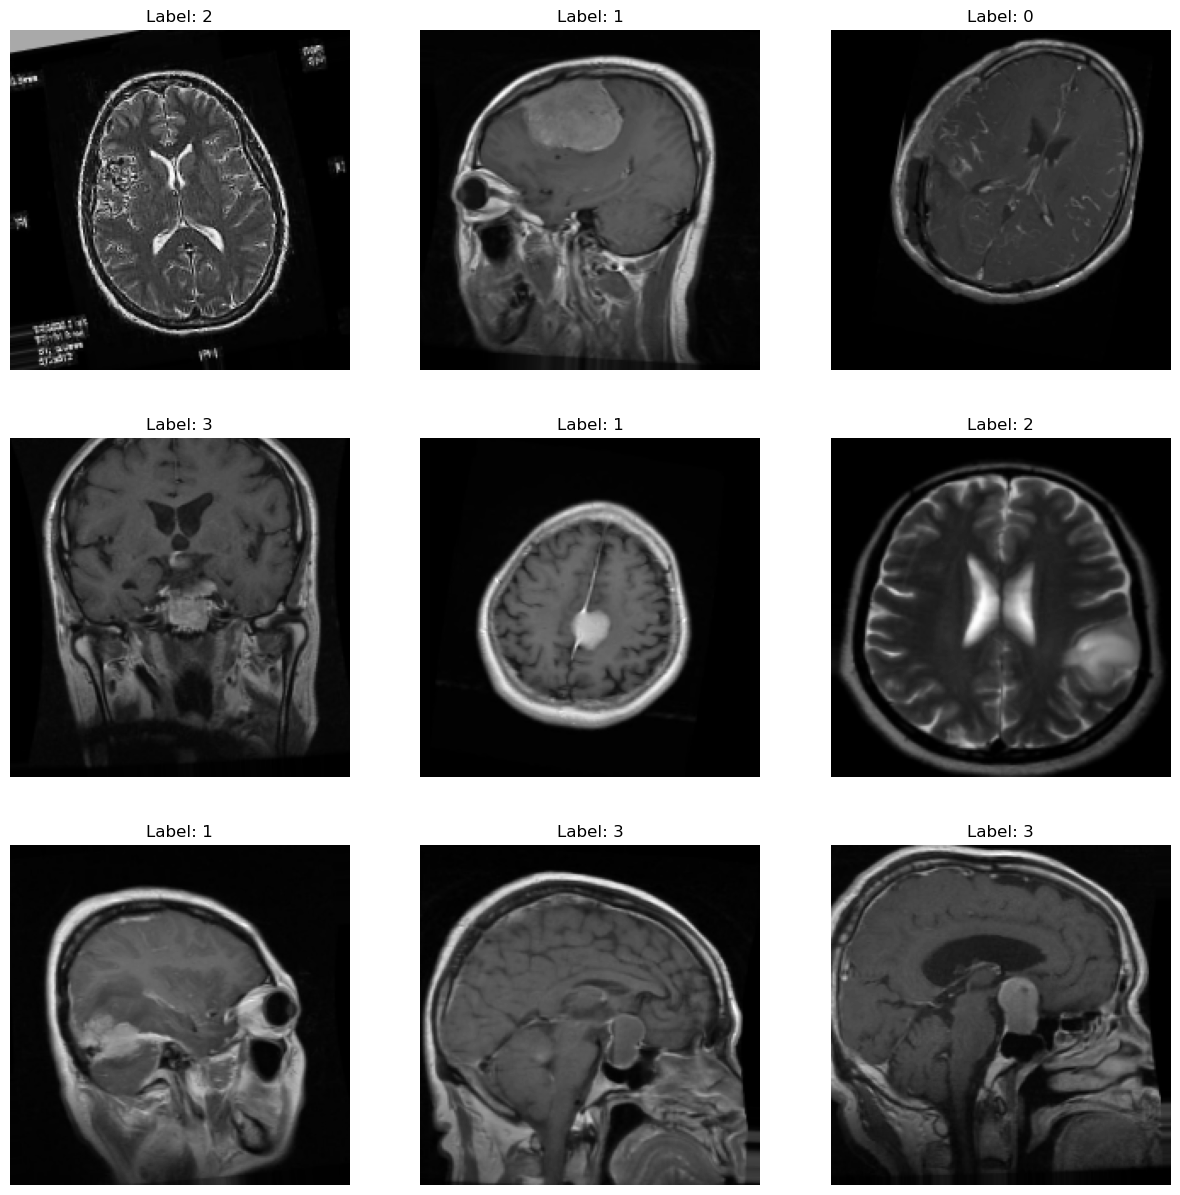

In [13]:
x_train_augmented = datagen.flow(x_train, y_train, batch_size=9, shuffle=True)
X_batch, y_batch = next(x_train_augmented)

plt.figure(figsize=(15, 15))
for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(X_batch[i].reshape(image_size, image_size), cmap='gray') 
    plt.axis('off')
    plt.title(f"Label: {np.argmax(y_batch[i])}")

plt.show()


In [14]:
train_datagen = tf.keras.preprocessing.image.ImageDataGenerator()
val_datagen = tf.keras.preprocessing.image.ImageDataGenerator()

train_data = train_datagen.flow(x_train, y_train, batch_size=32)
val_data = val_datagen.flow(x_val, y_val, batch_size=32)

## **Simple CNN**

In [15]:
def build_model(hp):
    model = Sequential()
    model.add(Conv2D(hp.Int('conv_1_filters', min_value=32, max_value=64, step=32),
                     (3, 3), activation='relu', input_shape=x_train.shape[1:]))
    model.add(MaxPooling2D((2, 2)))
    model.add(Conv2D(hp.Int('conv_2_filters', min_value=32, max_value=64, step=32),
                     (3, 3), activation='relu'))
    model.add(MaxPooling2D((2, 2)))
    model.add(Flatten())
    model.add(Dense(hp.Int('dense_units', min_value=64, max_value=128, step=64),
                    activation='relu'))
    model.add(Dense(len(labels), activation='softmax'))

    learning_rate = hp.Choice('learning_rate', values=[1e-4, 1e-3, 1e-2])
    optimizer_choice = hp.Choice('optimizer', values=['adam', 'sgd', 'rmsprop'])

    if optimizer_choice == 'adam':
        optimizer = Adam(learning_rate=learning_rate)
    elif optimizer_choice == 'sgd':
        optimizer = SGD(learning_rate=learning_rate)
    elif optimizer_choice == 'rmsprop':
        optimizer = RMSprop(learning_rate=learning_rate)
        
    model.compile(optimizer=optimizer,
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model

In [16]:
tuner = kt.Hyperband(
    build_model,
    objective='val_accuracy',
    max_epochs=10,
    factor=3,
    directory='simple_cnn_output',
    project_name='intro_to_cnn'
)


early_stopping = EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=1e-6)


tuner.search(train_data,
             epochs=20,
             validation_data=val_data,
             callbacks=[early_stopping, reduce_lr])


Reloading Tuner from simple_cnn_output\intro_to_cnn\tuner0.json


In [19]:
best_hyperparameters = tuner.get_best_hyperparameters(num_trials=1)[0]
print(f'Best hyperparameters: {best_hyperparameters.values}')

results_summary = tuner.results_summary()
if results_summary is not None:
    for trial_summary in results_summary.trials:
        print(f"Trial Summary:")
        print(trial_summary)
        print("\n")
else:
    print("No trials found in the results summary.")



model = tuner.hypermodel.build(best_hyperparameters)



history = model.fit(
    train_data,
    epochs=50,
    validation_data=val_data,
    callbacks=[early_stopping, reduce_lr]
)


test_loss, test_acc = model.evaluate(x_test, y_test)
print(f'Test accuracy: {test_acc}')

Best hyperparameters: {'conv_1_filters': 32, 'conv_2_filters': 64, 'dense_units': 128, 'learning_rate': 0.001, 'optimizer': 'adam', 'tuner/epochs': 10, 'tuner/initial_epoch': 4, 'tuner/bracket': 2, 'tuner/round': 2, 'tuner/trial_id': '0014'}
Results summary
Results in simple_cnn_output\intro_to_cnn
Showing 10 best trials
Objective(name="val_accuracy", direction="max")

Trial 0015 summary
Hyperparameters:
conv_1_filters: 32
conv_2_filters: 64
dense_units: 128
learning_rate: 0.001
optimizer: adam
tuner/epochs: 10
tuner/initial_epoch: 4
tuner/bracket: 2
tuner/round: 2
tuner/trial_id: 0014
Score: 0.9256343245506287

Trial 0014 summary
Hyperparameters:
conv_1_filters: 32
conv_2_filters: 64
dense_units: 128
learning_rate: 0.001
optimizer: adam
tuner/epochs: 4
tuner/initial_epoch: 2
tuner/bracket: 2
tuner/round: 1
tuner/trial_id: 0000
Score: 0.9011373519897461

Trial 0012 summary
Hyperparameters:
conv_1_filters: 64
conv_2_filters: 32
dense_units: 64
learning_rate: 0.001
optimizer: adam
tuner/

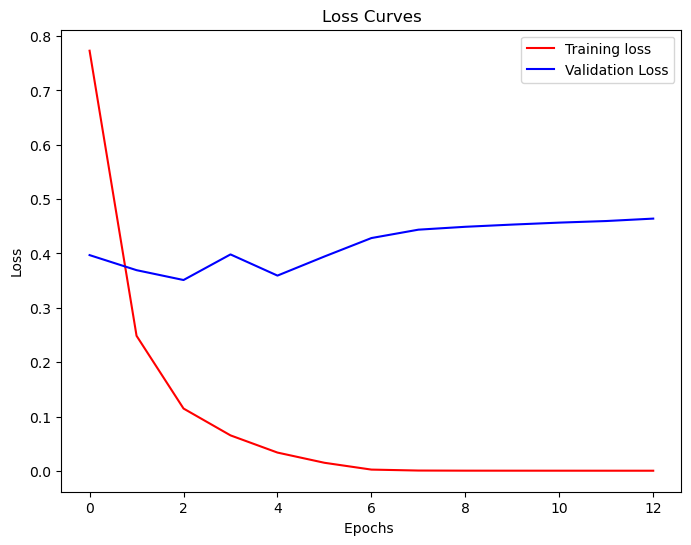

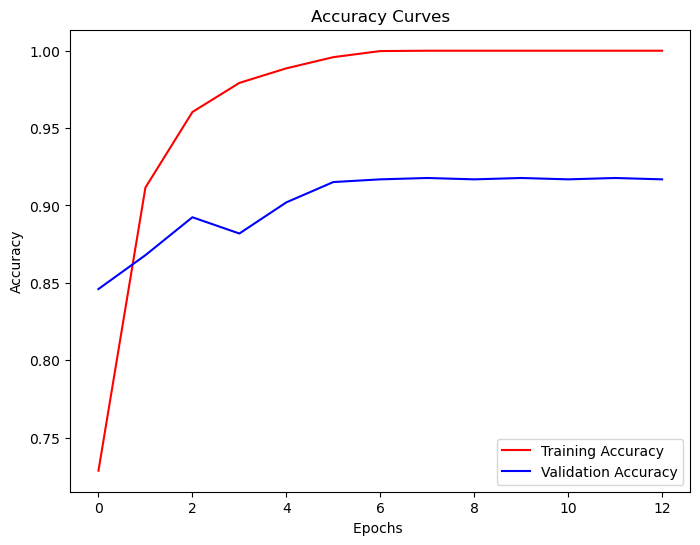

In [20]:
#Plot the Loss Curves
plt.figure(figsize=[8,6])
plt.plot(history.history['loss'],'r')
plt.plot(history.history['val_loss'],'b')
plt.legend(['Training loss', 'Validation Loss'])
plt.xlabel('Epochs ')
plt.ylabel('Loss')
plt.title('Loss Curves')
plt.show()

#Plot the Accuracy Curves
plt.figure(figsize=[8,6])
plt.plot(history.history['accuracy'],'r')
plt.plot(history.history['val_accuracy'],'b')
plt.legend(['Training Accuracy', 'Validation Accuracy'])
plt.xlabel('Epochs ')
plt.ylabel('Accuracy')
plt.title('Accuracy Curves')   
plt.show()

## **CNN with LSTM**

In [1]:
import os
import cv2
import numpy as np
from tqdm import tqdm
from sklearn.utils import shuffle
from sklearn.model_selection import train_test_split
import tensorflow as tf

# Labels for the different classes of tumors
labels = ['glioma', 'meningioma', 'notumor', 'pituitary']

# Lists to store the training and testing data
x_train = []
y_train = []
x_test = []
y_test = []

# Define the desired image size and patch size
image_size = 200
patch_size = 50
num_patches = (image_size // patch_size) ** 2  

def slice_image(image, patch_size):
    patches = []
    for i in range(0, image.shape[0], patch_size):
        for j in range(0, image.shape[1], patch_size):
            patch = image[i:i+patch_size, j:j+patch_size]
            patches.append(patch)
    return np.array(patches)

# Define the root dataset directory
dataset_dir = "./Brain_Tumor"  # Update this path based on your dataset location

# Load and preprocess the training and testing images
for label in labels:
    trainPath = os.path.join(dataset_dir, "Training", label)
    testPath = os.path.join(dataset_dir, "Testing", label)
    
    # Load and preprocess the training images
    for file in tqdm(os.listdir(trainPath)):
        image = cv2.imread(os.path.join(trainPath, file), 0)  # Load image in grayscale
        image = cv2.bilateralFilter(image, 2, 50, 50)  # Apply bilateral filter
        image = cv2.resize(image, (image_size, image_size))  # Resize image
        patches = slice_image(image, patch_size)  # Slice image into patches
        x_train.append(patches)  # Add patches to training data list
        y_train.append(labels.index(label))  # Add corresponding label
    
    # Load and preprocess the testing images
    for file in tqdm(os.listdir(testPath)):
        image = cv2.imread(os.path.join(testPath, file), 0)  # Load image in grayscale
        image = cv2.bilateralFilter(image, 2, 50, 50)  # Apply bilateral filter
        image = cv2.resize(image, (image_size, image_size))  # Resize image
        patches = slice_image(image, patch_size)  # Slice image into patches
        x_test.append(patches)  # Add patches to testing data list
        y_test.append(labels.index(label))  # Add corresponding label

# Convert the lists to numpy arrays and normalize the pixel values to [0, 1]
x_train = np.array(x_train)[..., np.newaxis] / 255.0  # Add a channel dimension
x_test = np.array(x_test)[..., np.newaxis] / 255.0  # Add a channel dimension

# Convert the labels to numpy arrays
y_train = np.array(y_train)
y_test = np.array(y_test)

# One-hot encode the labels
y_train = tf.keras.utils.to_categorical(y_train, num_classes=len(labels))
y_test = tf.keras.utils.to_categorical(y_test, num_classes=len(labels))

# Shuffle and split the data into training and validation sets
x_train, y_train = shuffle(x_train, y_train, random_state=42)
x_train, x_val, y_train, y_val = train_test_split(x_train, y_train, test_size=0.2, random_state=42)

# Print the shape of the datasets
print("Training data shape:", x_train.shape)
print("Validation data shape:", x_val.shape)
print("Test data shape:", x_test.shape)


100%|██████████| 300/300 [00:01<00:00, 231.08it/s]


Training data shape: (4569, 16, 50, 50, 1)
Validation data shape: (1143, 16, 50, 50, 1)
Test data shape: (1311, 16, 50, 50, 1)


In [3]:

train_dataset = tf.data.Dataset.from_tensor_slices((x_train, y_train))
val_dataset = tf.data.Dataset.from_tensor_slices((x_val, y_val))
test_dataset = tf.data.Dataset.from_tensor_slices((x_test, y_test))

batch_size = 32
train_dataset = train_dataset.shuffle(buffer_size=1024).batch(batch_size).prefetch(tf.data.experimental.AUTOTUNE)
val_dataset = val_dataset.batch(batch_size).prefetch(tf.data.experimental.AUTOTUNE)
test_dataset = test_dataset.batch(batch_size).prefetch(tf.data.experimental.AUTOTUNE)


In [3]:
import tensorflow as tf
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, LSTM, Dense, TimeDistributed, Input
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam, SGD, RMSprop
import keras_tuner as kt

def build_model(hp):
    input_shape = (num_patches, patch_size, patch_size, 1)
    inputs = tf.keras.Input(shape=input_shape)

    activation = hp.Choice('activation', values=['relu', 'leaky_relu', 'sigmoid'])

    x = tf.keras.layers.TimeDistributed(tf.keras.layers.Conv2D(hp.Int('conv_1_filters', min_value=32, max_value=128, step=32), 
                               (3, 3), activation=activation, padding='same'))(inputs)
    x = tf.keras.layers.TimeDistributed(tf.keras.layers.MaxPooling2D((2, 2)))(x)
    x = tf.keras.layers.TimeDistributed(tf.keras.layers.Conv2D(hp.Int('conv_2_filters', min_value=64, max_value=256, step=64), 
                               (3, 3), activation=activation, padding='same'))(x)
    x = tf.keras.layers.TimeDistributed(tf.keras.layers.MaxPooling2D((2, 2)))(x)
    x = tf.keras.layers.TimeDistributed(tf.keras.layers.Flatten())(x)

    x = tf.keras.layers.LSTM(hp.Int('lstm_units', min_value=64, max_value=256, step=64))(x)

    dense_activation = hp.Choice('dense_activation', values=['relu', 'leaky_relu', 'sigmoid'])
    x = tf.keras.layers.Dense(hp.Int('dense_units', min_value=64, max_value=256, step=64), activation=dense_activation)(x)
    outputs = tf.keras.layers.Dense(4, activation='softmax')(x)

    # Choose the optimizer
    optimizer_choice = hp.Choice('optimizer', values=['adam', 'sgd', 'rmsprop'])
    learning_rate = hp.Choice('learning_rate', values=[1e-2, 1e-3, 1e-4])

    if optimizer_choice == 'adam':
        optimizer = Adam(learning_rate=learning_rate)
    elif optimizer_choice == 'sgd':
        optimizer = SGD(learning_rate=learning_rate)
    elif optimizer_choice == 'rmsprop':
        optimizer = RMSprop(learning_rate=learning_rate)

    model = tf.keras.Model(inputs, outputs)
    model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])
    return model



In [4]:
from keras_tuner import RandomSearch

tuner = kt.Hyperband(
    build_model,
    objective='val_accuracy',
    max_epochs=10,
    factor=3,
    directory='my_dir',
    project_name='intro_to_kt'
)

In [7]:
early_stopping = EarlyStopping(monitor='val_accuracy', patience=15, verbose=1, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.1, patience=5, verbose=1, min_lr=1e-6)


tuner.search(train_dataset, epochs=20, validation_data=val_dataset, callbacks=[early_stopping, reduce_lr])


Trial 28 Complete [00h 04m 56s]
val_accuracy: 0.27646544575691223

Best val_accuracy So Far: 0.9011373519897461
Total elapsed time: 00h 39m 11s


In [8]:
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]

results_summary = tuner.results_summary()
if results_summary is not None:
    for trial_summary in results_summary.trials:
        print(f"Trial Summary:")
        print(trial_summary)
        print("\n")
else:
    print("No trials found in the results summary.")
    
print(f"""
The hyperparameter search is complete. Here are the best hyperparameters:
- Activation function: {best_hps.get('activation')}
- First Conv2D layer filters: {best_hps.get('conv_1_filters')}
- Second Conv2D layer filters: {best_hps.get('conv_2_filters')}
- LSTM units: {best_hps.get('lstm_units')}
- Dense layer activation function: {best_hps.get('dense_activation')}
- Dense layer units: {best_hps.get('dense_units')}
- Optimizer: {best_hps.get('optimizer')}
- Learning rate: {best_hps.get('learning_rate')}
""")


Results summary
Results in my_dir/intro_to_kt
Showing 10 best trials
Objective(name="val_accuracy", direction="max")

Trial 0014 summary
Hyperparameters:
activation: leaky_relu
conv_1_filters: 64
conv_2_filters: 128
lstm_units: 256
dense_activation: leaky_relu
dense_units: 256
optimizer: adam
learning_rate: 0.001
tuner/epochs: 4
tuner/initial_epoch: 2
tuner/bracket: 2
tuner/round: 1
tuner/trial_id: 0004
Score: 0.9011373519897461

Trial 0012 summary
Hyperparameters:
activation: relu
conv_1_filters: 64
conv_2_filters: 128
lstm_units: 128
dense_activation: leaky_relu
dense_units: 256
optimizer: adam
learning_rate: 0.001
tuner/epochs: 4
tuner/initial_epoch: 2
tuner/bracket: 2
tuner/round: 1
tuner/trial_id: 0008
Score: 0.8967629075050354

Trial 0022 summary
Hyperparameters:
activation: relu
conv_1_filters: 64
conv_2_filters: 128
lstm_units: 128
dense_activation: leaky_relu
dense_units: 256
optimizer: adam
learning_rate: 0.0001
tuner/epochs: 10
tuner/initial_epoch: 4
tuner/bracket: 1
tuner/r

In [9]:
model = tuner.hypermodel.build(best_hps)
model.summary()
history = model.fit(
    train_dataset,
    epochs=50,
    validation_data=val_dataset,
    callbacks=[reduce_lr]
)


test_acc = model.evaluate(test_dataset)
print(f'Test accuracy: {test_acc}')

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 16, 50, 50, 1)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_5              │ (None, 16, 50, 50, 64) │           640 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_6              │ (None, 16, 25, 25, 64) │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_7              │ (None, 16, 25, 25,     │        73,856 │
│ (TimeDistributed)               │ 128)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_8              │ (None, 16, 12, 12,     │             0 │
│ (TimeDistributed)               │ 128)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_9              │ (None, 16, 18432)      │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 256)            │    19,137,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,278,852 (73.54 MB)

 Trainable params: 19,278,852 (73.54 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
143/143 ━━━━━━━━━━━━━━━━━━━━ 23s 132ms/step - accuracy: 0.5475 - loss: 1.0128 - val_accuracy: 0.7699 - val_loss: 0.5587 - learning_rate: 0.0010
Epoch 2/50
143/143 ━━━━━━━━━━━━━━━━━━━━ 18s 127ms/step - accuracy: 0.8133 - loss: 0.4514 - val_accuracy: 0.8574 - val_loss: 0.3734 - learning_rate: 0.0010
Epoch 3/50
143/143 ━━━━━━━━━━━━━━━━━━━━ 18s 127ms/step - accuracy: 0.8898 - loss: 0.2794 - val_accuracy: 0.8731 - val_loss: 0.3416 - learning_rate: 0.0010
Epoch 4/50
143/143 ━━━━━━━━━━━━━━━━━━━━ 18s 127ms/step - accuracy: 0.9192 - loss: 0.2087 - val_accuracy: 0.8976 - val_loss: 0.3043 - learning_rate: 0.0010
Epoch 5/50
143/143 ━━━━━━━━━━━━━━━━━━━━ 18s 127ms/step - accuracy: 0.9569 - loss: 0.1033 - val_accuracy: 0.9160 - val_loss: 0.2805 - learning_rate: 0.0010
Epoch 6/50
143/143 ━━━━━━━━━━━━━━━━━━━━ 18s 127ms/step - accuracy: 0.9835 - loss: 0.0487 - val_accuracy: 0.9011 - val_loss: 0.3371 - learning_rate: 0.0010
Epoch 7/50
143/143 ━━━━━━━━━━━━━━━━━━━━ 18s 127ms/step - accuracy: 0.9

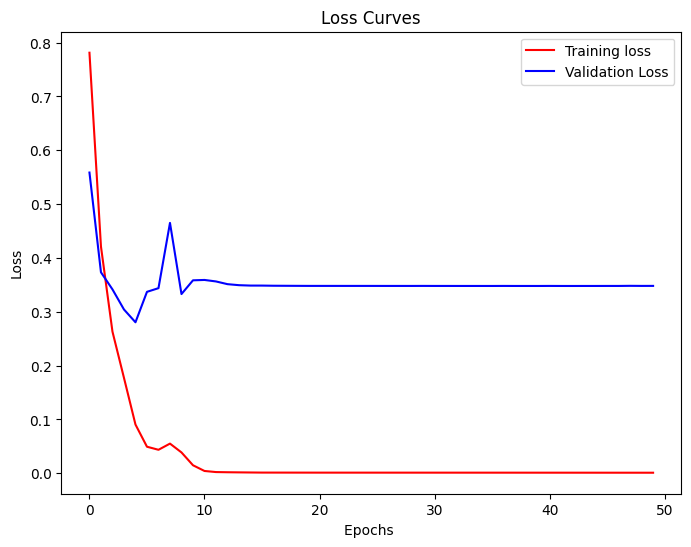

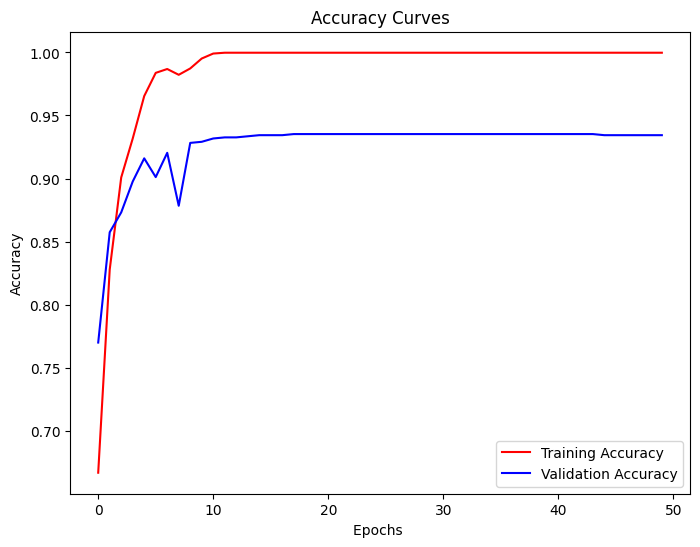

In [10]:
plt.figure(figsize=[8,6])
plt.plot(history.history['loss'],'r')
plt.plot(history.history['val_loss'],'b')
plt.legend(['Training loss', 'Validation Loss'])
plt.xlabel('Epochs ')
plt.ylabel('Loss')
plt.title('Loss Curves')
plt.show()

plt.figure(figsize=[8,6])
plt.plot(history.history['accuracy'],'r')
plt.plot(history.history['val_accuracy'],'b')
plt.legend(['Training Accuracy', 'Validation Accuracy'])
plt.xlabel('Epochs ')
plt.ylabel('Accuracy')
plt.title('Accuracy Curves')   
plt.show()

## **CNN with GRU**

In [4]:
import tensorflow as tf
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, GRU, Dense, TimeDistributed, Input
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam, SGD, RMSprop
import keras_tuner as kt

def build_model(hp):
    input_shape = (num_patches, patch_size, patch_size, 1)
    inputs = tf.keras.Input(shape=input_shape)
    activation = hp.Choice('activation', values=['relu', 'leaky_relu', 'sigmoid'])
    x = tf.keras.layers.TimeDistributed(tf.keras.layers.Conv2D(hp.Int('conv_1_filters', min_value=32, max_value=128, step=32), (3, 3), activation=activation, padding='same'))(inputs)
    x = tf.keras.layers.TimeDistributed(tf.keras.layers.MaxPooling2D((2, 2)))(x)
    x = tf.keras.layers.TimeDistributed(tf.keras.layers.Conv2D(hp.Int('conv_2_filters', min_value=64, max_value=256, step=64), (3, 3), activation=activation, padding='same'))(x)
    x = tf.keras.layers.TimeDistributed(tf.keras.layers.MaxPooling2D((2, 2)))(x)
    x = tf.keras.layers.TimeDistributed(tf.keras.layers.Flatten())(x)
    x = tf.keras.layers.GRU(hp.Int('gru_units', min_value=64, max_value=256, step=64), return_sequences=True)(x)
    x = tf.keras.layers.GRU(hp.Int('gru_units_2', min_value=64, max_value=256, step=64))(x)
    dense_activation = hp.Choice('dense_activation', values=['relu', 'leaky_relu', 'sigmoid'])
    x = Dropout(0.2)(x)  
    x = tf.keras.layers.Dense(hp.Int('dense_units', min_value=64, max_value=256, step=64), activation=dense_activation)(x)
    outputs = tf.keras.layers.Dense(4, activation='softmax')(x)
    
    
    optimizer_choice = hp.Choice('optimizer', values=['adam', 'sgd', 'rmsprop'])
    learning_rate = hp.Choice('learning_rate', values=[1e-2, 1e-3, 1e-4])
    if optimizer_choice == 'adam':
        optimizer = Adam(learning_rate=learning_rate)
    elif optimizer_choice == 'sgd':
        optimizer = SGD(learning_rate=learning_rate)
    elif optimizer_choice == 'rmsprop':
        optimizer = RMSprop(learning_rate=learning_rate)

    model = tf.keras.Model(inputs, outputs)
    model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])
    return model


In [5]:
early_stopping = EarlyStopping(monitor='val_accuracy', patience=15, verbose=1, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.1, patience=5, verbose=1, min_lr=1e-6)

tuner = kt.Hyperband(build_model, objective='val_accuracy', max_epochs=20, project_name='cnn_gru')

tuner.search(train_dataset, epochs=20, validation_data=val_dataset, callbacks=[early_stopping, reduce_lr])


Trial 30 Complete [00h 06m 40s]
val_accuracy: 0.5240594744682312

Best val_accuracy So Far: 0.9300087690353394
Total elapsed time: 01h 12m 24s


In [6]:
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
results_summary = tuner.results_summary()
if results_summary is not None:
    for trial_summary in results_summary.trials:
        print(f"Trial Summary:")
        print(trial_summary)
        print("\n")
else:
    print("No trials found in the results summary.")

print(f"""
The hyperparameter search is complete. Here are the best hyperparameters:
- Activation function: {best_hps.get('activation')}
- First Conv2D layer filters: {best_hps.get('conv_1_filters')}
- Second Conv2D layer filters: {best_hps.get('conv_2_filters')}
- First GRU layer units: {best_hps.get('gru_units')}
- Second GRU layer units: {best_hps.get('gru_units_2')}
- Dense layer activation function: {best_hps.get('dense_activation')}
- Dense layer units: {best_hps.get('dense_units')}
- Optimizer: {best_hps.get('optimizer')}
- Learning rate: {best_hps.get('learning_rate')}
""")

Results summary
Results in ./cnn_gru
Showing 10 best trials
Objective(name="val_accuracy", direction="max")

Trial 0027 summary
Hyperparameters:
activation: leaky_relu
conv_1_filters: 64
conv_2_filters: 256
gru_units: 192
gru_units_2: 192
dense_activation: sigmoid
dense_units: 128
optimizer: adam
learning_rate: 0.001
tuner/epochs: 20
tuner/initial_epoch: 0
tuner/bracket: 0
tuner/round: 0
Score: 0.9300087690353394

Trial 0016 summary
Hyperparameters:
activation: leaky_relu
conv_1_filters: 64
conv_2_filters: 192
gru_units: 192
gru_units_2: 192
dense_activation: relu
dense_units: 192
optimizer: rmsprop
learning_rate: 0.001
tuner/epochs: 20
tuner/initial_epoch: 7
tuner/bracket: 2
tuner/round: 2
tuner/trial_id: 0012
Score: 0.9265092015266418

Trial 0023 summary
Hyperparameters:
activation: leaky_relu
conv_1_filters: 64
conv_2_filters: 256
gru_units: 256
gru_units_2: 64
dense_activation: relu
dense_units: 256
optimizer: rmsprop
learning_rate: 0.001
tuner/epochs: 7
tuner/initial_epoch: 0
tune

In [7]:
model = tuner.hypermodel.build(best_hps)
model.summary()
history = model.fit(train_dataset, epochs=50, validation_data=val_dataset, callbacks=[reduce_lr])
test_loss, test_acc = model.evaluate(test_dataset)
print(f'Test accuracy: {test_acc}')

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 16, 50, 50, 1)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_5              │ (None, 16, 50, 50, 64) │           640 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_6              │ (None, 16, 25, 25, 64) │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_7              │ (None, 16, 25, 25,     │       147,712 │
│ (TimeDistributed)               │ 256)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_8              │ (None, 16, 12, 12,     │             0 │
│ (TimeDistributed)               │ 256)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_9              │ (None, 16, 36864)      │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_2 (GRU)                     │ (None, 16, 192)        │    21,345,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_3 (GRU)                     │ (None, 192)            │       222,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 192)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,741,316 (82.94 MB)

 Trainable params: 21,741,316 (82.94 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
143/143 ━━━━━━━━━━━━━━━━━━━━ 30s 175ms/step - accuracy: 0.5347 - loss: 1.0666 - val_accuracy: 0.7813 - val_loss: 0.5169 - learning_rate: 0.0010
Epoch 2/50
143/143 ━━━━━━━━━━━━━━━━━━━━ 24s 169ms/step - accuracy: 0.8318 - loss: 0.4351 - val_accuracy: 0.8828 - val_loss: 0.3283 - learning_rate: 0.0010
Epoch 3/50
143/143 ━━━━━━━━━━━━━━━━━━━━ 24s 169ms/step - accuracy: 0.9101 - loss: 0.2514 - val_accuracy: 0.8976 - val_loss: 0.2933 - learning_rate: 0.0010
Epoch 4/50
143/143 ━━━━━━━━━━━━━━━━━━━━ 24s 169ms/step - accuracy: 0.9487 - loss: 0.1457 - val_accuracy: 0.9116 - val_loss: 0.2621 - learning_rate: 0.0010
Epoch 5/50
143/143 ━━━━━━━━━━━━━━━━━━━━ 24s 169ms/step - accuracy: 0.9580 - loss: 0.1182 - val_accuracy: 0.9090 - val_loss: 0.2625 - learning_rate: 0.0010
Epoch 6/50
143/143 ━━━━━━━━━━━━━━━━━━━━ 24s 169ms/step - accuracy: 0.9762 - loss: 0.0688 - val_accuracy: 0.9265 - val_loss: 0.2609 - learning_rate: 0.0010
Epoch 7/50
143/143 ━━━━━━━━━━━━━━━━━━━━ 24s 169ms/step - accuracy: 0.9

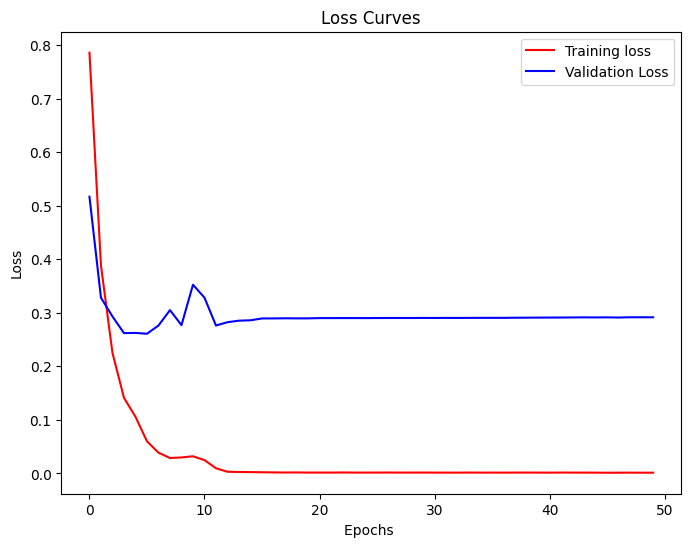

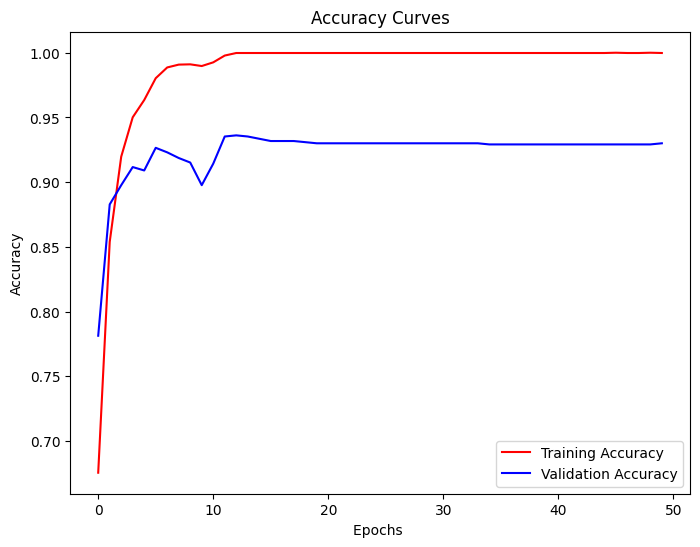

In [8]:
plt.figure(figsize=[8,6])
plt.plot(history.history['loss'],'r')
plt.plot(history.history['val_loss'],'b')
plt.legend(['Training loss', 'Validation Loss'])
plt.xlabel('Epochs ')
plt.ylabel('Loss')
plt.title('Loss Curves')
plt.show()

plt.figure(figsize=[8,6])
plt.plot(history.history['accuracy'],'r')
plt.plot(history.history['val_accuracy'],'b')
plt.legend(['Training Accuracy', 'Validation Accuracy'])
plt.xlabel('Epochs ')
plt.ylabel('Accuracy')
plt.title('Accuracy Curves')   
plt.show()